In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 找到 task-01-bandit 目录
# ------------------------------------------------------------

TASK_DIR = Path.cwd()

if TASK_DIR.name == "notebooks":
    TASK_DIR = TASK_DIR.parent

if str(TASK_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(TASK_DIR)
    )


from src import (
    TreasureHuntBandit,
    GreedyAgent,
    EpsilonGreedyAgent,
    UCBAgent,
    ThompsonSamplingAgent,
)

In [2]:
def run_experiment(
    env,
    agent,
    n_steps=1000,
):

    actions = []
    rewards = []

    q_history = []
    cumulative_rewards = []

    optimal_action_history = []

    total_reward = 0.0


    for step in range(n_steps):

        # 1. Agent 决策
        action = agent.select_action()

        # 2. Environment 返回 Reward
        reward = env.step(action)

        # 3. Agent 学习
        agent.update(
            action,
            reward
        )

        # 4. 保存实验数据
        total_reward += reward

        actions.append(action)

        rewards.append(reward)

        q_history.append(
            agent.Q.copy()
        )

        cumulative_rewards.append(
            total_reward
        )

        optimal_action_history.append(
            action
            == env.optimal_action
        )


    return {
        "actions":
            np.asarray(actions),

        "rewards":
            np.asarray(rewards),

        "Q_history":
            np.asarray(q_history),

        "cumulative_rewards":
            np.asarray(
                cumulative_rewards
            ),

        "optimal_actions":
            np.asarray(
                optimal_action_history
            ),

        "final_Q":
            agent.Q.copy(),

        "action_counts":
            agent.N.copy(),
    }

In [3]:
treasure_probs = [
    0.15,
    0.30,
    0.45,
    0.60,
    0.75,
]

In [4]:
env = TreasureHuntBandit(
    treasure_probs,
    seed=42,
)

agent = EpsilonGreedyAgent(
    n_actions=env.n_actions,
    epsilon=0.1,
    seed=123,
)

result = run_experiment(
    env,
    agent,
    n_steps=1000,
)


print(
    "True q*(a):",
    env.treasure_probs
)

print(
    "Estimated Q(a):",
    np.round(
        result["final_Q"],
        3
    )
)

print(
    "Action counts:",
    result["action_counts"]
)

print(
    "Average reward:",
    result["rewards"].mean()
)

print(
    "Optimal action rate:",
    result["optimal_actions"].mean()
)

True q*(a): [0.15 0.3  0.45 0.6  0.75]
Estimated Q(a): [0.125 0.278 0.458 0.5   0.743]
Action counts: [ 24  18  83  18 857]
Average reward: 0.692
Optimal action rate: 0.857


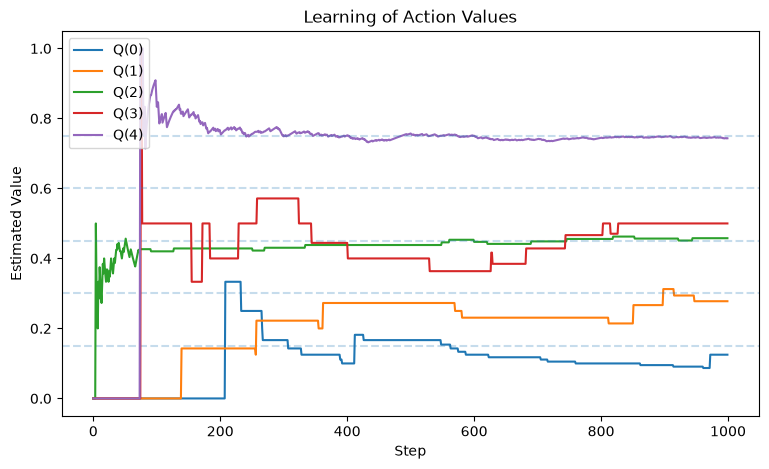

In [5]:
Q_history = result["Q_history"]

plt.figure(
    figsize=(9, 5)
)

for action in range(
    env.n_actions
):

    plt.plot(
        Q_history[:, action],
        label=f"Q({action})"
    )

    plt.axhline(
        env.treasure_probs[action],
        linestyle="--",
        alpha=0.25,
    )

plt.xlabel("Step")
plt.ylabel("Estimated Value")

plt.title(
    "Learning of Action Values"
)

plt.legend()

plt.show()

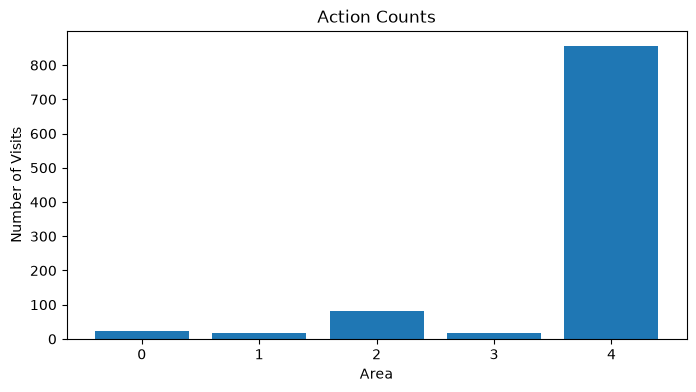

In [6]:
plt.figure(
    figsize=(8, 4)
)

plt.bar(
    np.arange(env.n_actions),
    result["action_counts"],
)

plt.xlabel("Area")
plt.ylabel("Number of Visits")

plt.title(
    "Action Counts"
)

plt.show()

In [7]:
def run_multiple_experiments(
    agent_class,
    agent_kwargs,
    treasure_probs,
    n_runs=100,
    n_steps=1000,
    base_seed=42,
):

    all_rewards = []
    all_optimal_actions = []


    for run in range(n_runs):

        env = TreasureHuntBandit(
            treasure_probs,
            seed=base_seed + run,
        )

        agent = agent_class(
            n_actions=env.n_actions,
            seed=base_seed + 10000 + run,
            **agent_kwargs,
        )

        result = run_experiment(
            env,
            agent,
            n_steps=n_steps,
        )

        all_rewards.append(
            result["rewards"]
        )

        all_optimal_actions.append(
            result["optimal_actions"]
        )


    return {
        "rewards":
            np.asarray(all_rewards),

        "optimal_actions":
            np.asarray(
                all_optimal_actions
            ),
    }

In [8]:
N_RUNS = 100
N_STEPS = 1000


experiments = {
    "Epsilon-Greedy": (
        EpsilonGreedyAgent,
        {
            "epsilon": 0.1
        }
    ),

    "UCB": (
        UCBAgent,
        {
            "c": 1.0
        }
    ),

    "Thompson Sampling": (
        ThompsonSamplingAgent,
        {}
    ),
}

In [9]:
results = {}


for name, (
    agent_class,
    agent_kwargs
) in experiments.items():

    results[name] = (
        run_multiple_experiments(
            agent_class=agent_class,
            agent_kwargs=agent_kwargs,
            treasure_probs=treasure_probs,
            n_runs=N_RUNS,
            n_steps=N_STEPS,
        )
    )

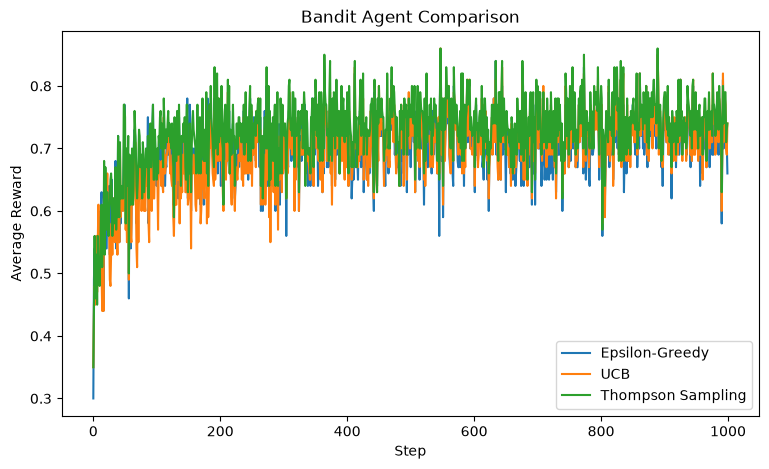

In [10]:
plt.figure(
    figsize=(9, 5)
)


for name, result in results.items():

    average_reward = (
        result["rewards"]
        .mean(axis=0)
    )

    plt.plot(
        average_reward,
        label=name,
    )


plt.xlabel("Step")
plt.ylabel("Average Reward")

plt.title(
    "Bandit Agent Comparison"
)

plt.legend()

plt.show()

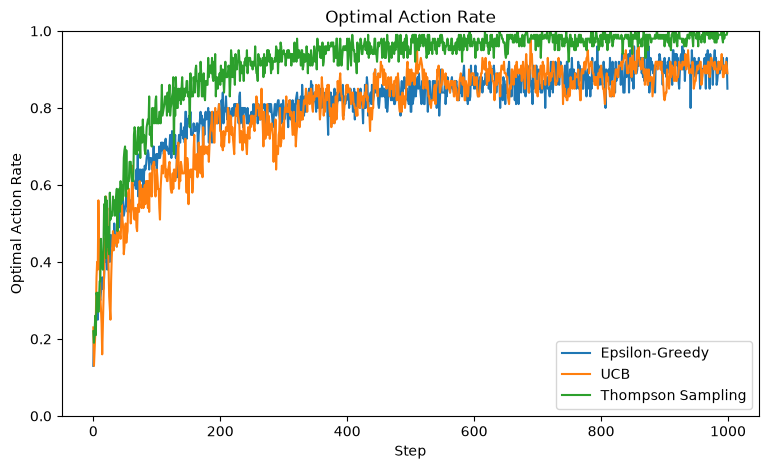

In [11]:
plt.figure(
    figsize=(9, 5)
)


for name, result in results.items():

    optimal_rate = (
        result[
            "optimal_actions"
        ]
        .mean(axis=0)
    )

    plt.plot(
        optimal_rate,
        label=name,
    )


plt.xlabel("Step")
plt.ylabel("Optimal Action Rate")

plt.ylim(0, 1)

plt.title(
    "Optimal Action Rate"
)

plt.legend()

plt.show()